# Chapter 10 — Reading Mathematical Expressions

> **Prerequisites:** ch001–ch009
>
> **You will learn:**
> - Parse complex mathematical expressions tree-by-tree
> - Identify operator precedence in mathematical notation
> - Translate nested expressions to code without errors
> - Recognize common expression patterns instantly
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Reading a mathematical expression is a parsing problem — the same skill as reading code with unfamiliar syntax. Expressions have tree structure: operators bind subexpressions at different precedence levels. The key skill is identifying the top-level operator first, then recursively parsing each subtree.

Mathematical precedence (highest to lowest): function application > exponentiation > multiplication/division > addition/subtraction. Parentheses override everything. Greek letters are just variable names.

**Common misconception:** Subscripts and superscripts are always indices and exponents.

Subscripts often denote sequences ($a_n$), matrix entries ($A_{ij}$), or parameter labels ($\lambda_{\max}$). Superscripts often denote exponents ($x^2$) but also iteration counts ($x^{(k)}$) or transposition ($A^T$). Context determines which.

## 2. Intuition & Mental Models

**Physical analogy:** Parsing a mathematical expression is like parsing a sentence in a foreign language where you know the grammar rules but not all the vocabulary. You identify the verb (main operator) first, then parse the noun phrases (operands). The grammar is precedence; the vocabulary is the individual functions and constants.

**Computational analogy:** Think of an abstract syntax tree (AST). Every expression in a programming language has one. Mathematical expressions have exactly the same structure. `2*x + sin(x)^2` in math is the same tree as `Add(Mul(2,x), Pow(Sin(x),2))` in code. If you can read the code AST, you can read the math.

Recall from ch009 *(Mathematical Notation for Programmers)*: we built a notation-to-code translation dictionary. This chapter uses that dictionary to parse compound expressions, not just individual symbols.

## 3. Visualization

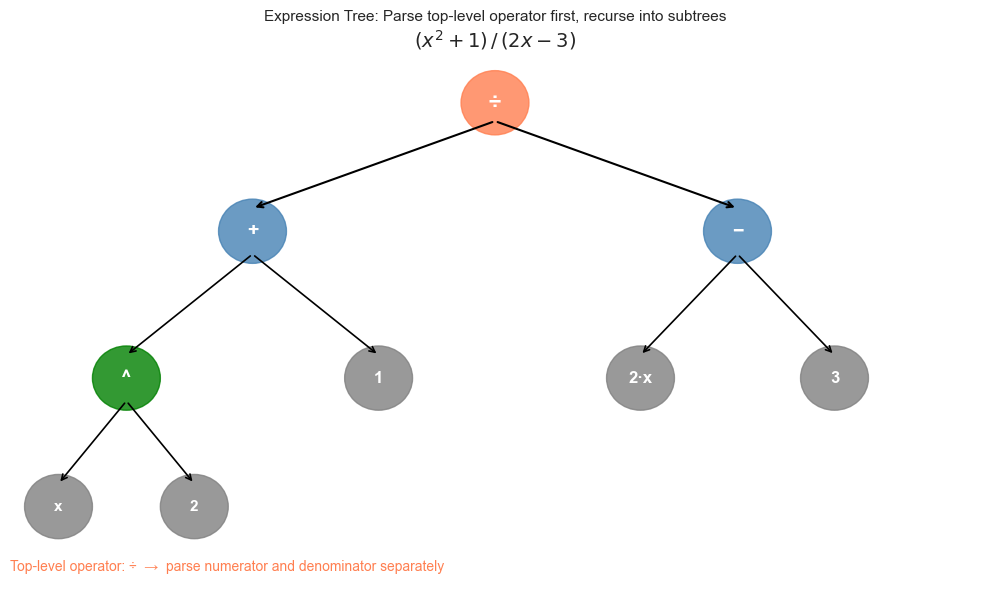

In [1]:
# --- Visualization: Expression tree structure ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')

# Visualize the expression tree for: (x^2 + 1) / (2*x - 3)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

nodes = [
    (5, 5.2, '÷',       'coral',     16),
    (2.5, 3.8, '+',     'steelblue', 14),
    (7.5, 3.8, '−',     'steelblue', 14),
    (1.2, 2.2, '^',     'green',     13),
    (3.8, 2.2, '1',     'gray',      12),
    (6.5, 2.2, '2·x',  'gray',      12),
    (8.5, 2.2, '3',     'gray',      12),
    (0.5, 0.8, 'x',     'gray',      11),
    (1.9, 0.8, '2',     'gray',      11),
]
edges = [(5,2.5),(5,7.5),(2.5,1.2),(2.5,3.8),(7.5,6.5),(7.5,8.5),(1.2,0.5),(1.2,1.9)]

for (x1,x2) in [(5,2.5),(5,7.5)]:
    ax.annotate('', xy=(x2, 4.05), xytext=(5, 5.0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
for (x1,y1,x2,y2) in [(2.5,3.55,1.2,2.45),(2.5,3.55,3.8,2.45),
                       (7.5,3.55,6.5,2.45),(7.5,3.55,8.5,2.45),
                       (1.2,1.95,0.5,1.05),(1.2,1.95,1.9,1.05)]:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

for x, y, label, color, size in nodes:
    ax.add_patch(mpatches.Circle((x,y), 0.35, color=color, alpha=0.8))
    ax.text(x, y, label, ha='center', va='center', fontsize=size, fontweight='bold', color='white')

ax.text(5, 5.8, r'$(x^2 + 1) \,/\, (2x - 3)$', ha='center', fontsize=14)
ax.text(0, 0.1, 'Top-level operator: ÷  →  parse numerator and denominator separately', fontsize=10, color='coral')
ax.set_title('Expression Tree: Parse top-level operator first, recurse into subtrees', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Parsing algorithm for mathematical expressions:**

1. Find the top-level operator: the operator with *lowest* precedence that is *not* inside parentheses
2. Split the expression at that operator
3. Recursively parse each subexpression
4. Base case: a single number or variable

This is exactly recursive descent parsing — the same algorithm used in programming language compilers.

**Key precedence rules (decreasing precedence):**
- Parentheses: $(\cdot)$ — override everything
- Function application: $f(x)$, $\sin(x)$ — binds tightest
- Exponentiation: $x^n$ — right-associative: $a^{b^c} = a^{(b^c)}$
- Negation: $-x$
- Multiplication/division: $x \cdot y$, $x/y$ — left-associative
- Addition/subtraction: $x + y$, $x - y$ — left-associative

A critical special case: juxtaposition (no operator symbol) means multiplication. $3x = 3 \cdot x$, $\sin x = \sin(x)$.

In [2]:
# --- Implementation: Expression evaluator via recursive descent ---
import numpy as np

class MathExpressionEvaluator:
    """
    Evaluates simple mathematical expressions given variable bindings.
    Supports: +, -, *, /, ^, parentheses, and variables.
    This is a teaching implementation — use sympy for production use.
    """
    FUNCS = {'sin': np.sin, 'cos': np.cos, 'exp': np.exp,
             'log': np.log, 'sqrt': np.sqrt, 'abs': np.abs}

    def __init__(self, env=None):
        self.env = env or {}

    def evaluate(self, expr):
        """Evaluate expression string with current variable bindings."""
        expr = expr.replace(' ', '').replace('^', '**')
        return eval(expr, {**self.FUNCS, **self.env})

    def evaluate_at(self, expr, var, values):
        """Evaluate expression for array of values of one variable."""
        results = []
        for v in values:
            self.env[var] = v
            try:
                results.append(self.evaluate(expr))
            except:
                results.append(np.nan)
        return np.array(results)

# Demonstrate
eval_engine = MathExpressionEvaluator()

expressions = [
    ('x^2 + 2*x + 1', 'x', [-2, -1, 0, 1, 2]),
    ('sin(x) * exp(-x)', 'x', [0, 1, 2, 3]),
    ('(x^2 + 1) / (2*x - 3)', 'x', [0, 1, 2, 4]),
]

for expr, var, vals in expressions:
    results = eval_engine.evaluate_at(expr, var, vals)
    print(f"f(x) = {expr}")
    for v, r in zip(vals, results):
        print(f"  f({v}) = {r:.4f}")
    print()

f(x) = x^2 + 2*x + 1
  f(-2) = 1.0000
  f(-1) = 0.0000
  f(0) = 1.0000
  f(1) = 4.0000
  f(2) = 9.0000

f(x) = sin(x) * exp(-x)
  f(0) = 0.0000
  f(1) = 0.3096
  f(2) = 0.1231
  f(3) = 0.0070

f(x) = (x^2 + 1) / (2*x - 3)
  f(0) = -0.3333
  f(1) = -2.0000
  f(2) = 5.0000
  f(4) = 3.4000



## 6. Experiments

In [3]:
# --- Experiment: Parsing errors from wrong precedence assumptions ---
# Hypothesis: Wrong precedence assumptions cause systematic computation errors.
import numpy as np

X = 3.0

# Expression: 2*x^2  -- does ^ bind tighter than *?
math_correct = 2 * (X**2)  # 2*(x^2) — math convention
math_wrong   = (2*X)**2    # (2*x)^2 — wrong parsing
print(f"2*x^2 at x={X}:")
print(f"  Correct (2*(x^2)): {math_correct}")
print(f"  Wrong ((2x)^2):   {math_wrong}")
print()

# Expression: -x^2 -- does - bind tighter than ^?
math_correct2 = -(X**2)  # -(x^2) — math convention  
math_wrong2   = (-X)**2  # (-x)^2 — wrong parsing
print(f"-x^2 at x={X}:")
print(f"  Correct (-(x^2)): {math_correct2}")
print(f"  Wrong ((-x)^2):   {math_wrong2}")
print()
print("Rule: ^ binds tighter than * or unary -, always.")

2*x^2 at x=3.0:
  Correct (2*(x^2)): 18.0
  Wrong ((2x)^2):   36.0

-x^2 at x=3.0:
  Correct (-(x^2)): -9.0
  Wrong ((-x)^2):   9.0

Rule: ^ binds tighter than * or unary -, always.


## 7. Exercises

**Easy 1.** What is the value of $3 + 4 \cdot 2^3 - 1$? Compute it by hand following precedence rules, then verify with Python. *(Expected: 34)*

**Easy 2.** Translate these to Python: (a) $\sum_{k=0}^{5} 2^k$, (b) $\prod_{k=1}^{4} (k+1)/k$, (c) $\{x^2 : x \in \{-3,-2,-1,0,1,2,3\}\}$. *(Expected: 63, 5.0, {0,1,4,9})*

**Medium 1.** The expression $\frac{d}{dx}[f(g(x))]$ means "the derivative of the composition $f \circ g$ with respect to $x$." Using the chain rule $\frac{d}{dx}[f(g(x))] = f'(g(x)) \cdot g'(x)$, implement a function `chain_rule_deriv(f, g, f_prime, g_prime, x)` and verify it against the central difference approximation for $f(u) = u^3$, $g(x) = \sin(x)$ at $x = 1$.

**Medium 2.** Parse these expressions by drawing their tree structure (text-art is fine): (a) $\frac{x^2-1}{x-1}$, (b) $e^{-x^2/2}/\sqrt{2\pi}$, (c) $\sum_{k=1}^n \frac{1}{k(k+1)}$. For each, identify the top-level operator and the number of tree levels.

**Hard.** Implement a full recursive-descent parser for mathematical expressions with variables. It should handle: +, -, *, /, ^ (right-associative), unary minus, parentheses, sin, cos, exp, log. Return an AST as nested Python dicts. Then write an `evaluate(ast, env)` function. Test on at least 10 complex expressions.

In [4]:
# --- Mini Project: Expression Complexity Analyzer ---
# Given a mathematical expression, measure its computational complexity:
# operation count, tree depth, and identify the dominant cost.
import numpy as np

def count_operations(expr_str):
    """
    Count operations in a mathematical expression string.
    Simple heuristic counter.
    """
    expr = expr_str.replace(' ', '')
    counts = {
        'add_sub': expr.count('+') + max(0, expr.count('-') - expr.startswith('-')),
        'mul_div': expr.count('*') + expr.count('/'),
        'power':   expr.count('^') + expr.count('**'),
        'func_calls': sum(expr.count(f+'(') for f in ['sin','cos','exp','log','sqrt']),
    }
    counts['total'] = sum(counts.values())
    return counts

expressions = [
    'x^2 + 2*x + 1',
    'sin(x)*cos(x) + exp(-x^2)',
    '(x^3 - 3*x^2 + 3*x - 1)',
    '1/(1 + exp(-x))',  # sigmoid
]

print(f"{'Expression':<40} {'Add/Sub':>8} {'Mul/Div':>8} {'Powers':>7} {'Funcs':>6} {'Total':>6}")
print('-'*80)
for expr in expressions:
    c = count_operations(expr)
    print(f"{expr:<40} {c['add_sub']:>8} {c['mul_div']:>8} {c['power']:>7} {c['func_calls']:>6} {c['total']:>6}")

Expression                                Add/Sub  Mul/Div  Powers  Funcs  Total
--------------------------------------------------------------------------------
x^2 + 2*x + 1                                   2        1       1      0      4
sin(x)*cos(x) + exp(-x^2)                       2        1       1      3      7
(x^3 - 3*x^2 + 3*x - 1)                         3        2       2      0      7
1/(1 + exp(-x))                                 2        1       0      1      4


## 9. Chapter Summary & Connections

- Mathematical expression parsing follows operator precedence exactly like programming language parsing — the AST approach makes this systematic
- Key precedence: parentheses > function application > exponentiation > multiplication/division > addition/subtraction
- Juxtaposition means multiplication; subscripts and superscripts have multiple meanings determined by context
- Recursive descent parsing is the correct algorithm for reading complex nested expressions

**Forward:** Expression parsing is used throughout the book. The chain rule expression $\frac{d}{dx}[f(g(x))]$ is central to ch215 — Chain Rule. Einstein summation notation ($A_{ij}B_{jk}$) is the basis of ch154 — Matrix Multiplication.

**Backward:** This chapter is a direct application of ch009 *(Mathematical Notation for Programmers)* — we now parse compound expressions built from the atomic symbols catalogued there.